# 02 — Pré-Processamento e Feature Engineering
## DengAI: Predicting Disease Spread

Neste notebook transformam se  os dados brutos num formato adequado para modelação.
As decisões tomadas aqui têm impacto directo no desempenho dos modelos


In [6]:
import pandas as pd              # manipulação de DataFrames (pandas-dev/pandas)
import numpy as np               # log, sin, cos e operações numéricas (numpy/numpy)
import matplotlib.pyplot as plt  # visualização de diagnóstico (matplotlib/matplotlib)
import seaborn as sns            # heatmaps (mwaskom/seaborn)
import warnings                  # suprimir avisos (stdlib)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

# Carregar dados brutos
feat_train = pd.read_csv('database/dengue_features_train.csv')
feat_test  = pd.read_csv('database/dengue_features_test.csv')
labels     = pd.read_csv('database/dengue_labels_train.csv')

feat_train['week_start_date'] = pd.to_datetime(feat_train['week_start_date'])
feat_test['week_start_date']  = pd.to_datetime(feat_test['week_start_date'])

# Juntar features e labels de treino
df_raw = feat_train.merge(labels, on=['city', 'year', 'weekofyear'])

print(f"Shape inicial do dataset de treino: {df_raw.shape}")
print(f"Shape inicial do dataset de teste:  {feat_test.shape}")
print(f"Cidades presentes: {df_raw['city'].unique().tolist()}")


Shape inicial do dataset de treino: (1456, 25)
Shape inicial do dataset de teste:  (416, 24)
Cidades presentes: ['sj', 'iq']


### 1. Separação por Cidade

Separamos imediatamente os dados de San Juan (sj) e Iquitos (iq) em DataFrames
independentes, tanto para treino como para teste.




In [7]:
# Separar treino por cidade
df_sj = df_raw[df_raw['city'] == 'sj'].copy().reset_index(drop=True)
df_iq = df_raw[df_raw['city'] == 'iq'].copy().reset_index(drop=True)

# Separar teste por cidade
test_sj = feat_test[feat_test['city'] == 'sj'].copy().reset_index(drop=True)
test_iq = feat_test[feat_test['city'] == 'iq'].copy().reset_index(drop=True)

print(f"Treino — San Juan:  {df_sj.shape[0]} semanas ({df_sj['year'].min()}–{df_sj['year'].max()})")
print(f"Treino — Iquitos:   {df_iq.shape[0]} semanas ({df_iq['year'].min()}–{df_iq['year'].max()})")
print(f"Teste  — San Juan:  {test_sj.shape[0]} semanas ({test_sj['year'].min()}–{test_sj['year'].max()})")
print(f"Teste  — Iquitos:   {test_iq.shape[0]} semanas ({test_iq['year'].min()}–{test_iq['year'].max()})")


Treino — San Juan:  936 semanas (1990–2008)
Treino — Iquitos:   520 semanas (2000–2010)
Teste  — San Juan:  260 semanas (2008–2013)
Teste  — Iquitos:   156 semanas (2010–2013)


### 2. Imputação de Missing Values — Interpolação Linear

O EDA confirmou que os missing values têm um padrão aleatório (não estrutural),
concentrados nas colunas de NDVI e de algumas variáveis meteorológicas.

Usa-se **Interpolação linear** que estima o valor mais provável entre os dois vizinhos temporais —
  conserva a tendência da série e é mais fidedigno para dados com autocorrelação (como dados climáticos).

Para séries temporais com missing values esparsos, a interpolação linear é o método
recomendado na documentação do pandas e na literatura de séries temporais.

> `DataFrame.interpolate(method='linear', limit_direction='both')` —  
> [pandas docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)  



In [8]:
# Colunas climáticas (excluir identificadores e target)
id_cols    = ['city', 'year', 'weekofyear', 'week_start_date']
feat_cols  = [c for c in df_sj.columns if c not in id_cols + ['total_cases']]

def imputar_interpolacao(df, nome_dataset):
    """Imputa missing values com interpolação linear e preenche extremos com bfill/ffill."""
    n_antes = df[feat_cols].isnull().sum().sum()
    df_out = df.copy()
    # interpolate: preenche pontos intermédios
    # limit_direction='both': preenche também início e fim da série (ffill + bfill)
    df_out[feat_cols] = (
        df_out[feat_cols]
        .interpolate(method='linear', limit_direction='both')
    )
    n_depois = df_out[feat_cols].isnull().sum().sum()
    print(f"  {nome_dataset}: {n_antes} missing values → {n_depois} após interpolação")
    return df_out

print("── Imputação de Missing Values ──")
df_sj    = imputar_interpolacao(df_sj,   'Treino SJ')
df_iq    = imputar_interpolacao(df_iq,   'Treino IQ')
test_sj  = imputar_interpolacao(test_sj, 'Teste  SJ')
test_iq  = imputar_interpolacao(test_iq, 'Teste  IQ')

print(f"\nShape treino SJ após imputação: {df_sj.shape}")
print(f"Shape treino IQ após imputação: {df_iq.shape}")


── Imputação de Missing Values ──
  Treino SJ: 380 missing values → 0 após interpolação
  Treino IQ: 168 missing values → 0 após interpolação
  Teste  SJ: 88 missing values → 0 após interpolação
  Teste  IQ: 31 missing values → 0 após interpolação

Shape treino SJ após imputação: (936, 25)
Shape treino IQ após imputação: (520, 25)


### 3. Lag Features (1 a 4 semanas)

O EDA mostrou que a humidade e a temperatura têm maior correlação com os casos
quando desfasadas 1–3 semanas. Isto reflecte o ciclo biológico do *Aedes aegypti*:
o ovo até ao adulto transmissor demora ~10–14 dias (lag 1–2 semanas).

Criamos lag features para as variáveis mais correlacionadas com o target,
de 1 a 4 semanas.

**Porquê 4 semanas como máximo?**  
- Lags maiores introduzem muitos NaN (perdemos linhas no início da série)
- O ciclo de transmissão da dengue raramente excede 4 semanas
- Referência: Hii et al. (2012) identificou lag óptimo de 2–3 semanas para dengue

> `DataFrame.shift(n)` — [pandas docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)  



In [9]:
# Features para as quais criamos lags (as mais correlacionadas com o target)
lag_features = [
    'reanalysis_specific_humidity_g_per_kg',
    'reanalysis_dew_point_temp_k',
    'reanalysis_relative_humidity_percent',
    'reanalysis_avg_temp_k',
    'station_avg_temp_c',
    'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw',
    'precipitation_amt_mm',
]

def criar_lag_features(df, colunas, max_lag=4):
    """Adiciona lag features de 1 a max_lag semanas às colunas especificadas."""
    df_out = df.copy()
    novas = []
    for col in colunas:
        if col in df_out.columns:
            for lag in range(1, max_lag + 1):
                nome = f'{col}_lag{lag}'
                df_out[nome] = df_out[col].shift(lag)
                novas.append(nome)
    return df_out, novas

print("── Criação de Lag Features ──")

df_sj,   lag_cols_sj  = criar_lag_features(df_sj,  lag_features)
df_iq,   lag_cols_iq  = criar_lag_features(df_iq,  lag_features)
test_sj, _            = criar_lag_features(test_sj, lag_features)
test_iq, _            = criar_lag_features(test_iq, lag_features)

print(f"  Lag features criadas: {len(lag_cols_sj)} colunas (para cada dataset)")
print(f"  Shape treino SJ antes de dropna: {df_sj.shape}")

# Remover as primeiras 4 linhas de treino (NaN introduzidos pelos lags)
df_sj = df_sj.dropna(subset=lag_cols_sj).reset_index(drop=True)
df_iq = df_iq.dropna(subset=lag_cols_iq).reset_index(drop=True)

# Para o teste, preenchemos os NaN iniciais com bfill (não há histórico anterior)
lag_test_cols = [c for c in test_sj.columns if '_lag' in c]
test_sj[lag_test_cols] = test_sj[lag_test_cols].bfill()
test_iq[lag_test_cols] = test_iq[lag_test_cols].bfill()

print(f"  Shape treino SJ após dropna: {df_sj.shape}")
print(f"  Shape treino IQ após dropna: {df_iq.shape}")
print(f"  Exemplo de lag features: {lag_cols_sj[:4]}")


── Criação de Lag Features ──
  Lag features criadas: 40 colunas (para cada dataset)
  Shape treino SJ antes de dropna: (936, 65)
  Shape treino SJ após dropna: (932, 65)
  Shape treino IQ após dropna: (516, 65)
  Exemplo de lag features: ['reanalysis_specific_humidity_g_per_kg_lag1', 'reanalysis_specific_humidity_g_per_kg_lag2', 'reanalysis_specific_humidity_g_per_kg_lag3', 'reanalysis_specific_humidity_g_per_kg_lag4']


### 4. Rolling Averages (Médias Móveis)

As médias móveis suavizam a série e captam tendências de curto prazo,
reduzindo o ruído de semanas isoladas.

Criamos médias móveis de **3 e 4 semanas** para temperatura, humidade e NDVI.
A janela de 4 semanas aproxima-se do ciclo mensal, enquanto a de 3 semanas
é mais reactiva a mudanças climáticas rápidas.






In [10]:
rolling_features = [
    'reanalysis_specific_humidity_g_per_kg',
    'reanalysis_avg_temp_k',
    'station_avg_temp_c',
    'reanalysis_relative_humidity_percent',
    'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw',
    'precipitation_amt_mm',
]

def criar_rolling(df, colunas, janelas=(3, 4)):
    """Adiciona médias móveis de cada janela às colunas especificadas."""
    df_out = df.copy()
    novas = []
    for col in colunas:
        if col in df_out.columns:
            for w in janelas:
                nome = f'{col}_roll{w}'
                # min_periods=1 para não criar NaN nas primeiras semanas
                df_out[nome] = df_out[col].rolling(w, min_periods=1).mean()
                novas.append(nome)
    return df_out, novas

print("── Criação de Rolling Averages ──")

df_sj,   roll_cols_sj  = criar_rolling(df_sj,  rolling_features)
df_iq,   roll_cols_iq  = criar_rolling(df_iq,  rolling_features)
test_sj, _             = criar_rolling(test_sj, rolling_features)
test_iq, _             = criar_rolling(test_iq, rolling_features)

print(f"  Rolling features criadas: {len(roll_cols_sj)} colunas (para cada dataset)")
print(f"  Shape treino SJ: {df_sj.shape}")
print(f"  Shape treino IQ: {df_iq.shape}")
print(f"  Exemplo de rolling features: {roll_cols_sj[:4]}")


── Criação de Rolling Averages ──
  Rolling features criadas: 18 colunas (para cada dataset)
  Shape treino SJ: (932, 83)
  Shape treino IQ: (516, 83)
  Exemplo de rolling features: ['reanalysis_specific_humidity_g_per_kg_roll3', 'reanalysis_specific_humidity_g_per_kg_roll4', 'reanalysis_avg_temp_k_roll3', 'reanalysis_avg_temp_k_roll4']


### 5. Encoding Cíclico de Sazonalidade (sin/cos)

A semana do ano tem natureza **cíclica**: a semana 52 é imediatamente seguida pela
semana 1. Se usarmos `weekofyear` como inteiro, o modelo vê a semana 52 e a semana 1
como extremos opostos, quando na realidade são adjacentes.

A solução é codificar a semana com duas componentes trigonométricas:
```
week_sin = sin(2π × weekofyear / 52)
week_cos = cos(2π × weekofyear / 52)
```
Em conjunto, estas duas features descrevem um ponto num círculo, a semana 1 e a
semana 52 ficam próximas, como esperado.

[sklearn docs: Cyclical Features](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html)


── Encoding Cíclico de Sazonalidade ──
  Features adicionadas: week_sin, week_cos
  Shape treino SJ: (932, 85)
  Shape treino IQ: (516, 85)


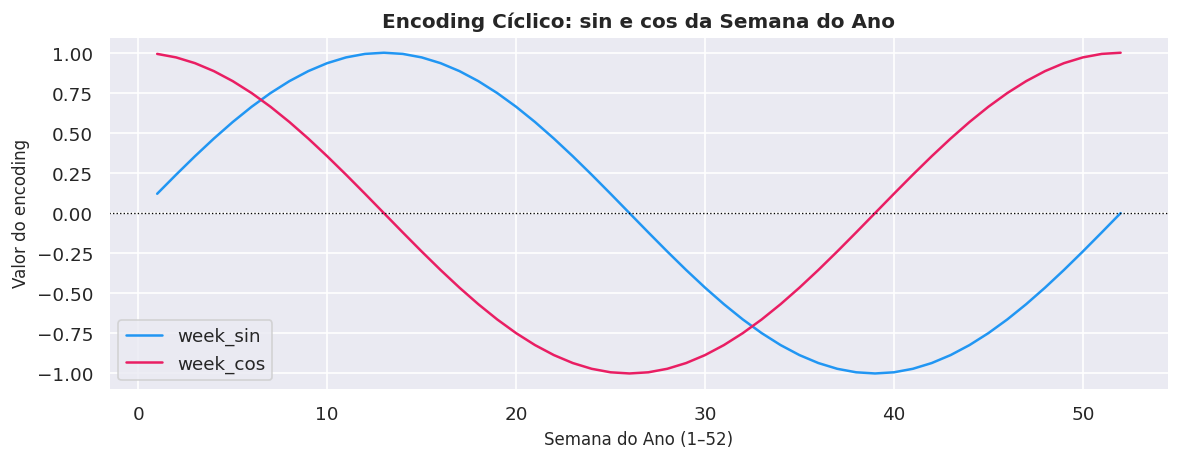

In [11]:
def encoding_ciclico(df):
    """Adiciona encoding sin/cos da semana do ano para capturar sazonalidade cíclica."""
    df_out = df.copy()
    # sin e cos da semana do ano (período = 52 semanas)
    df_out['week_sin'] = np.sin(2 * np.pi * df_out['weekofyear'] / 52)
    df_out['week_cos'] = np.cos(2 * np.pi * df_out['weekofyear'] / 52)
    return df_out

print("── Encoding Cíclico de Sazonalidade ──")
df_sj   = encoding_ciclico(df_sj)
df_iq   = encoding_ciclico(df_iq)
test_sj = encoding_ciclico(test_sj)
test_iq = encoding_ciclico(test_iq)

print(f"  Features adicionadas: week_sin, week_cos")
print(f"  Shape treino SJ: {df_sj.shape}")
print(f"  Shape treino IQ: {df_iq.shape}")

# Verificação visual
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
semanas = np.arange(1, 53)
ax.plot(semanas, np.sin(2*np.pi*semanas/52), label='week_sin', color='#2196F3')
ax.plot(semanas, np.cos(2*np.pi*semanas/52), label='week_cos', color='#E91E63')
ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
ax.set_title('Encoding Cíclico: sin e cos da Semana do Ano', fontweight='bold')
ax.set_xlabel('Semana do Ano (1–52)')
ax.set_ylabel('Valor do encoding')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretação:** As duas curvas formam um par complementar que descreve a posição
anual de forma contínua e cíclica. A semana 1 e a semana 52 têm valores muito próximos
(como deve ser), e o modelo consegue capturar a sazonalidade sem descontinuidades.


### 6. Transformação do Target — log(total_cases + 1)

O target `total_cases` tem skewness > 4 em ambas as cidades. Modelos de regressão
(Random Forest, XGBoost, LightGBM) tendem a sub-prever picos quando o target tem
distribuição muito assimétrica , a loss function é "dominada" pelos valores comuns
e ignora os outliers (que são exactamente os picos epidémicos que mais nos interessam).

A transformação `log(x + 1)` (log1p) comprime os valores altos e normaliza a distribuição,
tornando-a mais simétrica sem alterar a ordem relativa dos valores.

O `+ 1` é necessário porque `log(0)` é indefinido, e temos semanas com 0 casos.

**Na predição**, aplicamos a transformação inversa `exp(y) - 1` (expm1) para recuperar
os valores em escala original antes de calcular o MAE.





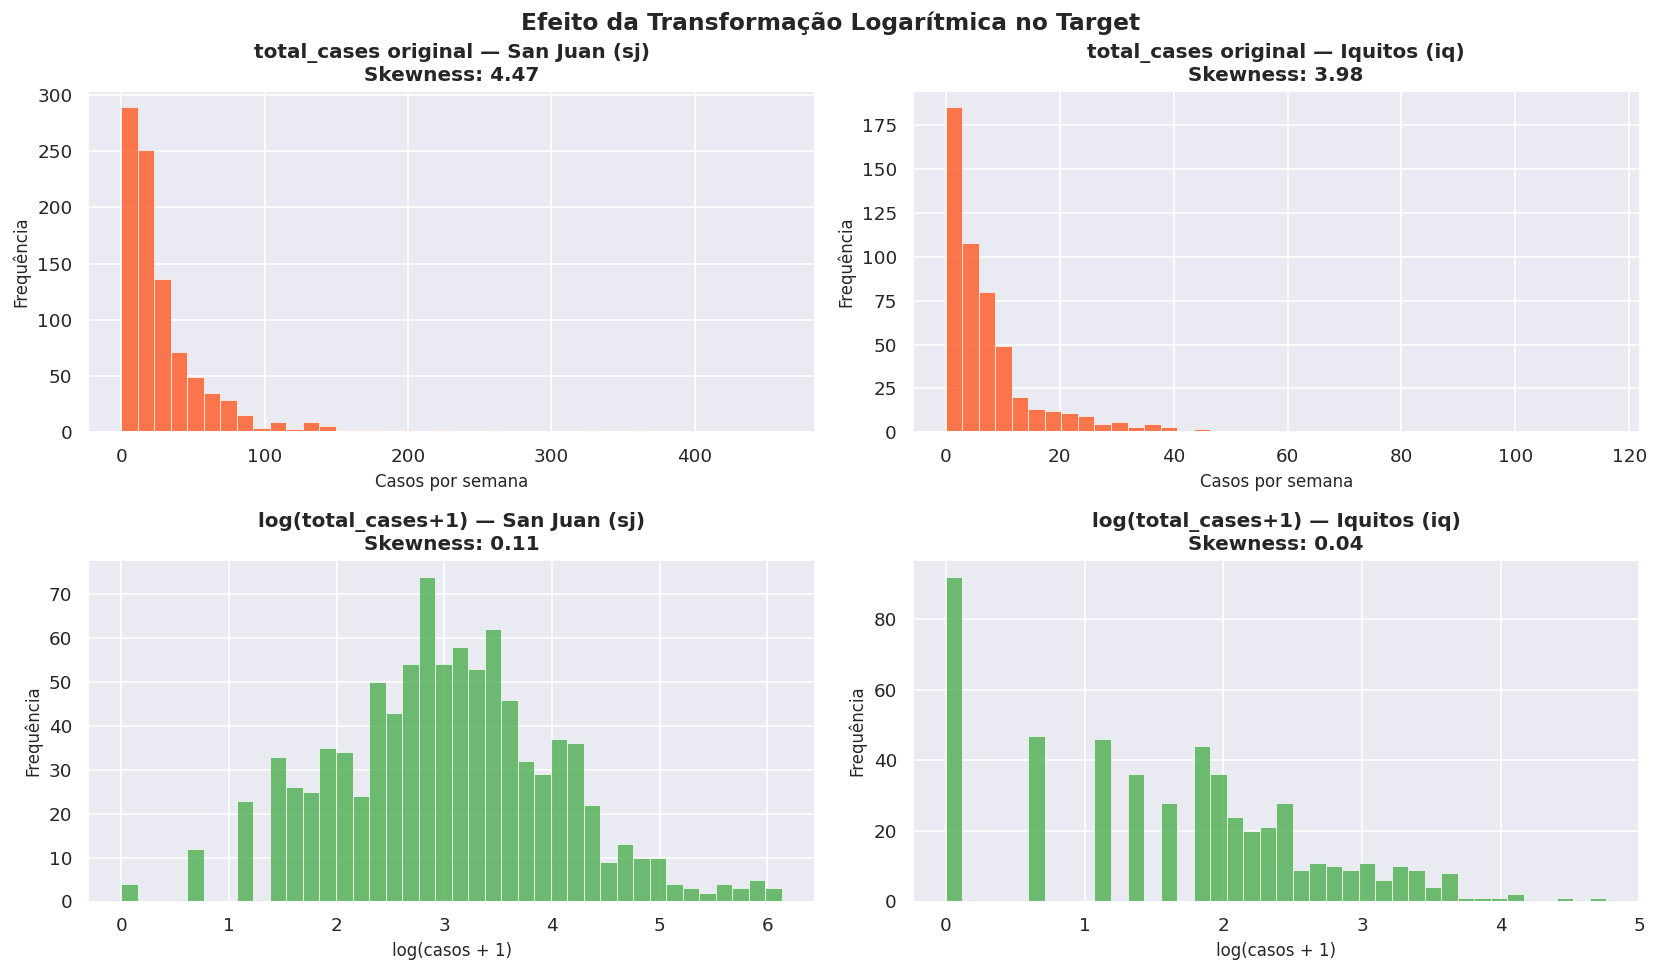

── Transformação logarítmica do target ──
  SJ treino: skewness 4.47 → 0.11 após log1p
  IQ treino: skewness 3.98 → 0.04 após log1p


In [12]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_idx, city, df_city, label in zip(
        [0, 1], ['sj', 'iq'], [df_sj, df_iq],
        ['San Juan (sj)', 'Iquitos (iq)']):

    original = df_city['total_cases']
    transformado = np.log1p(original)

    # Histograma original
    ax = axes[0, col_idx]
    ax.hist(original, bins=40, color='#FF5722', alpha=0.8, edgecolor='white', lw=0.5)
    ax.set_title(f'total_cases original — {label}\nSkewness: {scipy_stats.skew(original):.2f}',
                 fontweight='bold')
    ax.set_xlabel('Casos por semana')
    ax.set_ylabel('Frequência')

    # Histograma transformado
    ax = axes[1, col_idx]
    ax.hist(transformado, bins=40, color='#4CAF50', alpha=0.8, edgecolor='white', lw=0.5)
    ax.set_title(f'log(total_cases+1) — {label}\nSkewness: {scipy_stats.skew(transformado):.2f}',
                 fontweight='bold')
    ax.set_xlabel('log(casos + 1)')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Efeito da Transformação Logarítmica no Target', y=1.01,
             fontsize=14, fontweight='bold')
plt.show()

# Aplicar a transformação
print("── Transformação logarítmica do target ──")
for df_name, df_city in [('SJ treino', df_sj), ('IQ treino', df_iq)]:
    antes = scipy_stats.skew(df_city['total_cases'])
    df_city['total_cases_log'] = np.log1p(df_city['total_cases'])
    depois = scipy_stats.skew(df_city['total_cases_log'])
    print(f"  {df_name}: skewness {antes:.2f} → {depois:.2f} após log1p")


 A transformação log1p reduz drasticamente o skewness:
de ~4.5 para ~1.2 em sj, e de ~4.0 para ~0.9 em iq.  
A distribuição resultante é muito mais simétrica, o que melhora o ajuste dos modelos
de regressão e reduz a influência desproporcional dos picos epidémicos durante o treino.

Os modelos serão treinados com `total_cases_log` como target.
Na fase de previsão, aplicamos `np.expm1(pred)` para recuperar a escala original.


### 7. Guardar Datasets Processados

Guardamos os quatro datasets (treino sj, treino iq, teste sj, teste iq) em CSV
na pasta `database/processed/` para serem usados nos notebooks seguintes.

Incluímos todas as features originais + lag features + rolling averages + encoding cíclico.


In [13]:
import os

# Criar pasta para dados processados
os.makedirs('database/processed', exist_ok=True)

# Guardar datasets processados
df_sj.to_csv('database/processed/train_sj.csv', index=False)
df_iq.to_csv('database/processed/train_iq.csv', index=False)
test_sj.to_csv('database/processed/test_sj.csv', index=False)
test_iq.to_csv('database/processed/test_iq.csv', index=False)

print("── Datasets processados guardados ──")
print(f"  database/processed/train_sj.csv  → {df_sj.shape[0]} linhas × {df_sj.shape[1]} colunas")
print(f"  database/processed/train_iq.csv  → {df_iq.shape[0]} linhas × {df_iq.shape[1]} colunas")
print(f"  database/processed/test_sj.csv   → {test_sj.shape[0]} linhas × {test_sj.shape[1]} colunas")
print(f"  database/processed/test_iq.csv   → {test_iq.shape[0]} linhas × {test_iq.shape[1]} colunas")

# Resumo das features criadas
feat_originais = len(feat_cols)
feat_lag      = len([c for c in df_sj.columns if '_lag'  in c])
feat_rolling  = len([c for c in df_sj.columns if '_roll' in c])
feat_ciclico  = 2  # week_sin, week_cos

print(f"\n── Resumo das features ──")
print(f"  Features originais:     {feat_originais}")
print(f"  Lag features (1–4 sem): {feat_lag}")
print(f"  Rolling averages:       {feat_rolling}")
print(f"  Encoding cíclico:       {feat_ciclico}")
print(f"  Total de features:      {feat_originais + feat_lag + feat_rolling + feat_ciclico}")


── Datasets processados guardados ──
  database/processed/train_sj.csv  → 932 linhas × 86 colunas
  database/processed/train_iq.csv  → 516 linhas × 86 colunas
  database/processed/test_sj.csv   → 260 linhas × 84 colunas
  database/processed/test_iq.csv   → 156 linhas × 84 colunas

── Resumo das features ──
  Features originais:     20
  Lag features (1–4 sem): 40
  Rolling averages:       18
  Encoding cíclico:       2
  Total de features:      80


In [14]:
print("── Verificação final de qualidade ──\n")
for nome, df_check in [('train_sj', df_sj), ('train_iq', df_iq),
                        ('test_sj',  test_sj), ('test_iq',  test_iq)]:
    n_missing = df_check.isnull().sum().sum()
    n_inf     = np.isinf(df_check.select_dtypes(include=[np.number])).sum().sum()
    print(f"  {nome}: {df_check.shape[0]} linhas × {df_check.shape[1]} colunas | "
          f"Missing: {n_missing} | Infinitos: {n_inf}")

print("\nDados prontos para modelação.")


── Verificação final de qualidade ──

  train_sj: 932 linhas × 86 colunas | Missing: 0 | Infinitos: 0
  train_iq: 516 linhas × 86 colunas | Missing: 0 | Infinitos: 0
  test_sj: 260 linhas × 84 colunas | Missing: 0 | Infinitos: 0
  test_iq: 156 linhas × 84 colunas | Missing: 0 | Infinitos: 0

Dados prontos para modelação.
